# Machine Translation

# Data Loading, Cleaning, and Splitting

- Libraries such as `torch`, `nltk`, and `tokenizers` are imported early to support later stages of the notebook (training, evaluation, and visualization).  
- The `clean_sentence` function lowercases text, trims whitespace, and removes punctuation. This reduces data noise and helps the model learn cleaner word patterns.  
- The `load_and_clean_data` function reads parallel data from `Source.nl` (Dutch) and `translations_scored.en` (English), applies text cleaning, and verifies that both files contain the same number of lines using an `assert` statement.  
- A brief sample of cleaned sentence pairs is printed for quick inspection. This ensures cleaning did not corrupt the dataset and that source and target lines still align correctly.  
- The optional `limit` parameter restricts dataset size to speed up experimentation and model prototyping.  
- The data is split into a 90/10 ratio for training and validation:

```python
split_idx = int(0.9 * len(src_texts))
train_src, valid_src = src_texts[:split_idx], src_texts[split_idx:]
train_tgt, valid_tgt = tgt_texts[:split_idx], tgt_texts[split_idx:]
```
This ensures that most data is used for model learning while a smaller portion is reserved for validation, allowing evaluation of generalization during training.

In [25]:
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from torch import nn
import random
from collections import Counter
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors
import nltk
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt
import seaborn as sns
import re

nltk.download('punkt')

def clean_sentence(sentence):
    sentence = sentence.strip().lower()
    sentence = re.sub(r"[^\w\s]", "", sentence) 
    return sentence

def load_and_clean_data(src_path, tgt_path, limit=None):
    with open(src_path, "r", encoding="utf-8") as f:
        src_lines = [clean_sentence(line) for line in f if line.strip()]
    with open(tgt_path, "r", encoding="utf-8") as f:
        tgt_lines = [clean_sentence(line) for line in f if line.strip()]

    if limit:
        src_lines, tgt_lines = src_lines[:limit], tgt_lines[:limit]

    assert len(src_lines) == len(tgt_lines), "Source and target files must have the same number of lines"

    unclean_src = sum(s != s.strip() for s in src_lines)
    unclean_tgt = sum(t != t.strip() for t in tgt_lines)
    print(f"Clean check → Source: {unclean_src} unclean lines, Target: {unclean_tgt} unclean lines")

    print("\nSample cleaned lines:")
    for _ in range(3):
        idx = random.randint(0, len(src_lines) - 1)
        print(f"NL: {repr(src_lines[idx])}")
        print(f"EN: {repr(tgt_lines[idx])}")
        print("-" * 40)

    return src_lines, tgt_lines

src_texts, tgt_texts = load_and_clean_data(
    "./Translations/Source.nl",
    "./Translations/translations_scored.en",
    limit=10000
)

split_idx = int(0.9 * len(src_texts))
train_src, valid_src = src_texts[:split_idx], src_texts[split_idx:]
train_tgt, valid_tgt = tgt_texts[:split_idx], tgt_texts[split_idx:]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\19102\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Clean check → Source: 962 unclean lines, Target: 1472 unclean lines

Sample cleaned lines:
NL: 'dat is de mop'
EN: 'that s the gag'
----------------------------------------
NL: ' ja hij praat'
EN: ' oh yes it speaks'
----------------------------------------
NL: 'om te zien hoe slaven uit het stof kropen'
EN: 'crassus has certainly played a part a very workman like role'
----------------------------------------


# Tokenizer Training

- The tokenizer is initialized with `Tokenizer(models.BPE())`, which segments text into frequent subword units rather than full words. This approach balances vocabulary size and generalization, helping the model handle rare and unseen words more effectively.  
- `pre_tokenizers.Whitespace()` ensures text is first split by spaces before subword processing begins. This keeps word boundaries consistent.  
- The `BpeTrainer` defines key training parameters:
  - `vocab_size=100000` sets the maximum number of unique tokens in the vocabulary.
  - `min_frequency=2` ensures only tokens appearing at least twice are included, filtering out noise.
  - `special_tokens` adds placeholders for unknown words (`<unk>`), padding (`<pad>`), and sentence boundaries (`<bos>`, `<eos>`).  

- The helper function `get_training_corpus()` iterates over all Dutch–English sentence pairs and yields both sides of each pair. This trains a shared vocabulary that works for both source and target languages, improving translation consistency.  
- The tokenizer is then trained directly from these text samples using `tokenizer.train_from_iterator(...)`.  
- Finally, the vocabulary size is printed, and the trained tokenizer is stored in `tokenizer_original` to preserve it before any later modifications or wrappers.

In [58]:
tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.BpeTrainer(
    vocab_size=100000,
    min_frequency=2,
    special_tokens=["<unk>", "<pad>", "<bos>", "<eos>"]
)

def get_training_corpus():
    for src, tgt in zip(train_src, train_tgt):
        yield src
        yield tgt

tokenizer.train_from_iterator(get_training_corpus(), trainer=trainer)
print("Tokenizer trained with vocab size:", tokenizer.get_vocab_size())

tokenizer_original = tokenizer

Tokenizer trained with vocab size: 8784


# Dataset Encoding and DataLoader Preparation

- The `encode_sentence` function tokenizes a sentence using the trained BPE tokenizer and truncates it to a fixed `max_length`.  
  - If a sentence is shorter than `max_length`, it is padded with the `<pad>` token ID to ensure all sequences have equal length.  
  - This padding is necessary for efficient batch processing in PyTorch.  

- The `TranslationDataset` class wraps the source and target text pairs into a PyTorch-compatible dataset.  
  - Each item returned by `__getitem__` is a tuple of tensors: `(source_ids, target_ids)`.  
  - The dataset’s length matches the number of sentence pairs available.  

- The `collate_fn` function defines how individual samples are combined into a batch.  
  - `pad_sequence` aligns sentences within a batch to the same length using the `<pad>` token ID.  
  - This ensures consistent tensor shapes across batches for both the source and target sequences.  

- Two dataloaders are created:
  - `train_loader` randomly shuffles batches during training to improve generalization.
  - `valid_loader` does not shuffle, preserving sentence order for consistent evaluation.

These dataloaders efficiently feed batches of padded token sequences into the neural translation model during training and validation.

In [27]:
def encode_sentence(sentence, max_length=32):
    ids = tokenizer.encode(sentence).ids
    ids = ids[:max_length]
    padding = [tokenizer.token_to_id("<pad>")] * (max_length - len(ids))
    return ids + padding

class TranslationDataset(Dataset):
    def __init__(self, src_texts, tgt_texts):
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src = encode_sentence(self.src_texts[idx])
        tgt = encode_sentence(self.tgt_texts[idx])
        return torch.tensor(src), torch.tensor(tgt)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, padding_value=tokenizer.token_to_id("<pad>"))
    tgt_batch = pad_sequence(tgt_batch, padding_value=tokenizer.token_to_id("<pad>"))
    return src_batch, tgt_batch

train_loader = DataLoader(
    TranslationDataset(train_src, train_tgt),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    TranslationDataset(valid_src, valid_tgt),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)


# Model Architecture: Encoder, Attention, Decoder, Seq2Seq

VOCAB_SIZE is taken from the tokenizer. The same vocabulary is used for both source (Dutch) and target (English), which means the model learns a shared token space.

Encoder  
- The encoder maps the input sentence (in token IDs) to a sequence of hidden states.  
- It uses an embedding layer to turn token IDs into vectors, followed by a GRU that processes the sequence over time.  
- The encoder returns:
  - outputs: all hidden states for every time step in the source sentence  
  - hidden: the final hidden state, which summarizes the whole source sentence and is used to initialize the decoder

Attention  
- The attention module learns which source tokens are relevant for predicting the next target token.  
- For each decoding step, it looks at:
  - the current decoder state (hidden)
  - all encoder outputs (encoder_outputs)  
- It computes a score for each source position and returns a normalized attention distribution over the source tokens.  
- This gives the decoder the ability to "look back" at specific words instead of relying only on a single summary vector.

Decoder  
- The decoder generates the translation one token at a time.  
- It embeds the previous token, runs a GRU, and uses attention to build a context vector that focuses on the most relevant encoder outputs.  
- The context vector and the GRU output are concatenated and passed through a linear layer to predict the next token's vocabulary distribution.  
- The decoder returns:
  - prediction: logits for the next token over the entire vocabulary  
  - hidden: the new decoder state to carry into the next step  
  - attn_weights: the attention distribution over the source tokens for this step, which we later visualize

Seq2Seq  
- The Seq2Seq class wraps encoder and decoder into one training-time loop.  
- The forward pass takes:
  - src: source batch (shape [src_len, batch_size])  
  - tgt: target batch (shape [tgt_len, batch_size])  
  - teacher_forcing_ratio: probability of feeding the true next token instead of the model’s own guess  
- The model encodes the source once, then iteratively decodes each timestep of the target. At every step it either:
  - uses the ground truth token (teacher forcing), or
  - uses its own last prediction (autoregressive decoding)

The output of Seq2Seq is a tensor of predicted logits over the vocabulary for every position in the target sentence. This is what we use to compute the training loss.


In [28]:
VOCAB_SIZE = tokenizer.get_vocab_size()

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.repeat(src_len, 1, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=0)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim + hid_dim, hid_dim)
        self.attention = Attention(hid_dim)
        self.fc_out = nn.Linear(hid_dim * 2, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        attn_weights = self.attention(hidden, encoder_outputs) 
        context = torch.sum(attn_weights.unsqueeze(2) * encoder_outputs, dim=0).unsqueeze(0)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc_out(torch.cat((output, context), dim=2).squeeze(0))
        return prediction, hidden, attn_weights

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = tgt.shape[1]
        tgt_len = tgt.shape[0]
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(tgt_len, batch_size, vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = tgt[0, :]

        for t in range(1, tgt_len):
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = tgt[t] if teacher_force else top1

        return outputs


# Model Initialization and Training Loop

The device is set to GPU if available for faster training: 
```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
```
Model parameters include `VOCAB_SIZE` from the tokenizer, `EMB_DIM = 256` and `HID_DIM = 512`, which define the embedding and hidden state sizes to allow the model to capture more complex patterns. The model is created using 
```python
enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM) 
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)
```

The loss function and optimizer are defined as
```python 
PAD_IDX = tokenizer.token_to_id("<pad>") 
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX) 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
``` 
The `ignore_index=PAD_IDX` ensures that padded tokens do not contribute to the loss, and Adam optimizer provides efficient and adaptive gradient updates.

The training loop iterates over epochs and batches: for each batch, source and target tensors are moved to the device, the model output is computed and reshaped for the cross-entropy loss, gradients are backpropagated, and weights are updated. Gradient clipping (`torch.nn.utils.clip_grad_norm_`) prevents exploding gradients by limiting the norm to 1. The average training loss per epoch is printed to monitor progress. This setup ensures the model learns translations efficiently while maintaining numerical stability and leveraging GPU acceleration.

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

EMB_DIM = 256
HID_DIM = 512

enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)

PAD_IDX = tokenizer.token_to_id("<pad>")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

num_epochs = 50
patience = 2
best_valid_loss = float('inf')
epochs_no_improve = 0
start_teacher_forcing = 0.5
min_teacher_forcing = 0.1
decay_rate = 0.95

for epoch in range(num_epochs):
    teacher_forcing_ratio = max(start_teacher_forcing * (decay_rate ** epoch), min_teacher_forcing)
    model.train()
    total_loss = 0

    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=teacher_forcing_ratio)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        tgt = tgt[1:].reshape(-1)
        loss = criterion(output, tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for src, tgt in valid_loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt, teacher_forcing_ratio=0)
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            tgt = tgt[1:].reshape(-1)
            loss = criterion(output, tgt)
            valid_loss += loss.item()
    valid_loss /= len(valid_loader)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}, Teacher Forcing: {teacher_forcing_ratio:.2f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

Using device: cuda
Epoch 1, Train Loss: 6.4868, Valid Loss: 6.1329, Teacher Forcing: 0.50
Epoch 2, Train Loss: 5.2404, Valid Loss: 5.9492, Teacher Forcing: 0.47
Epoch 3, Train Loss: 4.0268, Valid Loss: 5.9865, Teacher Forcing: 0.45
Epoch 4, Train Loss: 2.9307, Valid Loss: 6.1915, Teacher Forcing: 0.43
Early stopping triggered after 4 epochs.


# Sentence Translation Function

This function performs translation using the trained Seq2Seq model and the custom BPE tokenizer.  
It generates an English translation for a given Dutch input sentence through iterative decoding.

The model is set to evaluation mode to disable dropout and gradient tracking:

```python
model.eval()
```
The input sentence is tokenized, converted to token IDs, and padded to a fixed maximum length.
Padding ensures the tensor has a consistent shape across sentences:
```python
src_ids = tokenizer.encode(sentence.strip()).ids[:max_len]
padding = [tokenizer.token_to_id("<pad>")] * (max_len - len(src_ids))
src_ids += padding
src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)
```
The encoder processes the source tokens to produce hidden representations, and the decoder begins generating the target sequence starting with the <bos> (beginning-of-sentence) token:
```python
encoder_outputs, hidden = model.encoder(src_tensor)
input = torch.tensor([tokenizer.token_to_id("<bos>")]).to(device)
```
The decoding loop runs up to max_len steps. At each iteration:
1. The decoder predicts the next token.
2. The token with the highest probability (top1) is selected.
3. If <eos> (end-of-sentence) is reached, decoding stops.
4. A check prevents the model from repeating the same token indefinitely by replacing consecutive duplicates with <pad>.
```python
output, hidden, _ = model.decoder(input, hidden, encoder_outputs)
top1 = output.argmax(1)

if top1.item() == tokenizer.token_to_id("<eos>"):
    break
if top1.item() == prev_top1:
    top1 = torch.tensor([tokenizer.token_to_id("<pad>")]).to(device)
```
Each generated token ID is stored in a list, then decoded back into text using the tokenizer’s decode method:
```python
translated = tokenizer.decode(result_ids)
return translated
```
This function performs greedy decoding (always choosing the highest-probability next token).
While simple, it provides fast, deterministic translations suitable for evaluating model behavior and visualizing attention patterns.

In [30]:
def translate_sentence(model, sentence, tokenizer, max_len=64, device=device):
    model.eval()

    src_ids = tokenizer.encode(sentence.strip()).ids[:max_len]
    padding = [tokenizer.token_to_id("<pad>")] * (max_len - len(src_ids))
    src_ids += padding
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        input = torch.tensor([tokenizer.token_to_id("<bos>")]).to(device)
        result_ids = []
        prev_top1 = None

        for _ in range(max_len):
            output, hidden, _ = model.decoder(input, hidden, encoder_outputs)
            top1 = output.argmax(1)

            if top1.item() == tokenizer.token_to_id("<eos>"):
                break

            if top1.item() == prev_top1:
                top1 = torch.tensor([tokenizer.token_to_id("<pad>")]).to(device)

            result_ids.append(top1.item())
            prev_top1 = top1.item()
            input = top1

    translated = tokenizer.decode(result_ids)
    return translated

# Model Evaluation with BLEU Score

Measuring how well the model translates by comparing its outputs to reference translations using the BLEU metric.  
The model is set to evaluation mode to ensure stable results, and `sacrebleu` is used for standardized scoring:

```python
bleu = sacrebleu.corpus_bleu(preds, [refs])
```
The function tests a subset of the validation data and prints the BLEU score:
```python
print(f"Validation BLEU score: {bleu_val:.2f}")
```
A higher BLEU score means the model’s translations are closer to human references.

In [31]:
import sacrebleu

def evaluate_bleu(model, src_texts, tgt_texts, tokenizer, max_len=64, device=device):
    model.eval()
    preds, refs = [], []

    for src_sentence, tgt_sentence in zip(src_texts, tgt_texts):
        pred = translate_sentence(model, src_sentence, tokenizer, max_len=max_len, device=device)
        preds.append(pred.strip())
        refs.append(tgt_sentence.strip())

    bleu = sacrebleu.corpus_bleu(preds, [refs])
    return bleu.score

bleu_val = evaluate_bleu(model, valid_src[:500], valid_tgt[:500], tokenizer)
print(f"Validation BLEU score: {bleu_val:.2f}")

Validation BLEU score: 0.29


# Random Translation Example

Demonstrating the model’s translation ability on a randomly chosen Dutch sentence from the dataset.  
A random sentence is selected and passed through the translation function:

```python
test_sentence = random.choice(src_texts)
print("English (pred):", translate_sentence(model, test_sentence, tokenizer))
```
This allows for a quick, qualitative check of how well the model performs beyond numeric metrics like BLEU.

In [32]:
import random
test_sentence = random.choice(src_texts)
print("Dutch:", test_sentence)
print("English (pred):", translate_sentence(model, test_sentence, tokenizer))

Dutch: het was mooi schatjes
English (pred): it was beautiful ies was beautiful ies was it was beautiful ies was it was beautiful ies was it was beautiful it was beautiful ies was it was beautiful it was beautiful ies was it was beautiful it was beautiful it was beautiful ies was it was beautiful it was beautiful it was beautiful it was beautiful was it was beautiful it


# Beam Search Decoding

This function generates a translation using beam search instead of simple greedy decoding.  
Beam search keeps multiple candidate translations in parallel and picks the best-scoring one at the end.

The model encodes the source sentence once and initializes the beam with just the beginning-of-sentence token:

```python
beam = [{
    "tokens": [BOS],
    "score": 0.0,
    "hidden": hidden,
}]
```
At every decoding step, each partial hypothesis in the beam is extended with several possible next tokens.
For each extension, the model scores how likely that next token is:

```python
output, hidden_next, attn_weights = model.decoder(last_token, b["hidden"], encoder_outputs)
log_probs = torch.log_softmax(output.squeeze(0).squeeze(0), dim=-1)
topk_logp, topk_indices = torch.topk(log_probs, beam_size)
```
A repetition penalty is applied to discourage the model from repeating the same token over and over:

```python
log_probs[tok] = log_probs[tok] - rep_log * cnt
```
Each candidate keeps track of
- the generated token sequence so far,
- the running score (sum of log probabilities),
- the hidden state needed for the next step.

Longer sequences naturally accumulate more negative log probability, so a length penalty is used to make shorter and longer candidates comparable:

```python
return c["score"] / ( (L ** length_penalty) )
```
When decoding stops, all finished candidates (those that ended with <eos>) are ranked, and the best-scoring sequence is selected, stripped of <bos> / <eos>, and decoded back into text:

```python
translated = tokenizer.decode(tokens)
return translated
```
Compared to greedy decoding, beam search explores multiple good continuations instead of committing to a single guess at each step. This usually produces more fluent and complete translations.

In [33]:
import math
import torch
import torch.nn.functional as F
from collections import Counter

def translate_beam(
    model,
    sentence,
    tokenizer,
    beam_size=5,
    max_len=64,
    length_penalty=0.7,
    repetition_penalty=1.2,
    device=None
):

    device = device or next(model.parameters()).device
    model.eval()

    BOS = tokenizer.token_to_id("<bos>")
    EOS = tokenizer.token_to_id("<eos>")
    PAD = tokenizer.token_to_id("<pad>")

    src_ids = tokenizer.encode(sentence.strip()).ids[:max_len]
    if len(src_ids) == 0:
        return ""
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor) 
        src_len = encoder_outputs.shape[0]

        beam = [{
            "tokens": [BOS],
            "score": 0.0,
            "hidden": hidden,

        }]
        completed = []

        for step in range(1, max_len + 1):
            all_candidates = []

            for b in beam:
                last = b["tokens"][-1]

                if last == EOS:
                    all_candidates.append(b)
                    continue

                last_token = torch.tensor([last]).to(device)
                output, hidden_next, attn_weights = model.decoder(last_token, b["hidden"], encoder_outputs)

                log_probs = torch.log_softmax(output.squeeze(0).squeeze(0), dim=-1)

                if repetition_penalty is not None and repetition_penalty > 1.0:
                    rep_log = math.log(repetition_penalty)
                    counts = Counter(b["tokens"])

                    for tok, cnt in counts.items():
                        if tok == BOS:
                            continue
                        if tok < log_probs.numel(): 
                            log_probs[tok] = log_probs[tok] - rep_log * cnt

                topk_logp, topk_indices = torch.topk(log_probs, beam_size)
                for lp, idx in zip(topk_logp.tolist(), topk_indices.tolist()):
                    candidate = {
                        "tokens": b["tokens"] + [int(idx)],
                        "score": b["score"] + float(lp),
                        "hidden": hidden_next,
                    }
                    all_candidates.append(candidate)

            if not all_candidates:
                break

            def normalized_score(c):
                L = len(c["tokens"]) - 1 
                if L <= 0:
                    return c["score"]
                if length_penalty is None or length_penalty == 0:
                    return c["score"]
                return c["score"] / ( (L ** length_penalty) )

            all_candidates.sort(key=normalized_score, reverse=True)
            beam = all_candidates[:beam_size]

            newly_completed = [b for b in beam if b["tokens"][-1] == EOS]
            for nc in newly_completed:
                if nc not in completed:
                    completed.append(nc)

            if len(completed) >= beam_size:
                break

        finals = completed if completed else beam
        finals.sort(key=normalized_score, reverse=True)
        best = finals[0]

        tokens = best["tokens"]

        if tokens and tokens[0] == BOS:
            tokens = tokens[1:]

        if EOS in tokens:
            eos_pos = tokens.index(EOS)
            tokens = tokens[:eos_pos]

        translated = tokenizer.decode(tokens)
        return translated

# Sampling-Based Decoding

This function generates a translation by sampling tokens instead of always taking the single most likely next token. The result is that it can produce alternative phrasings and more diverse translations.

The source sentence is encoded once, and decoding starts from the beginning-of-sentence token:

```python
encoder_outputs, hidden = model.encoder(src_tensor)
input_token = torch.tensor([BOS]).to(device)
```
At each decoding step, the decoder predicts a distribution over the next token:

```python
output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)
logits = output.squeeze(0).squeeze(0)
probs = F.softmax(logits, dim=-1)
```
Instead of picking only the single best token (greedy) or tracking several best candidates (beam search), this method samples from the model's next-token distribution. Sampling is restricted to the top k most likely tokens to keep outputs fluent:

```python
topk_probs, topk_idx = torch.topk(probs, k=min(top_k, probs.size(0)))
chosen = torch.multinomial(topk_probs, 1).item()
next_id = int(topk_idx[chosen].item())
```
A repetition penalty is applied to reduce loops and avoid the model getting stuck repeating the same token:

```python
logits[t] = logits[t] - math.log(repetition_penalty)
```
Decoding stops once the end-of-sentence token is produced, and the collected token IDs are decoded back into text:

```python
return tokenizer.decode(output_ids)
```
Compared to greedy decoding and beam search, sampling produces more varied translations and can reveal alternative valid outputs, which is useful for qualitative analysis.

In [34]:
def translate_sampling(
    model,
    sentence,
    tokenizer,
    max_len=64,
    top_k=5,
    repetition_penalty=1.2,
    device=None
):

    device = device or next(model.parameters()).device
    model.eval()

    BOS = tokenizer.token_to_id("<bos>")
    EOS = tokenizer.token_to_id("<eos>")
    PAD = tokenizer.token_to_id("<pad>")

    src_ids = tokenizer.encode(sentence.strip()).ids[:max_len]
    if len(src_ids) == 0:
        return ""
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)
        input_token = torch.tensor([BOS]).to(device)
        output_ids = []
        for _ in range(max_len):
            output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)
            logits = output.squeeze(0).squeeze(0)  # [vocab]
            if repetition_penalty is not None and repetition_penalty > 1.0:
                for t in set(output_ids):
                    if t < logits.shape[0]:
                        logits[t] = logits[t] - math.log(repetition_penalty)

            probs = F.softmax(logits, dim=-1)
            topk_probs, topk_idx = torch.topk(probs, k=min(top_k, probs.size(0)))
            chosen = torch.multinomial(topk_probs, 1).item()
            next_id = int(topk_idx[chosen].item())

            if next_id == EOS:
                break
            output_ids.append(next_id)
            input_token = torch.tensor([next_id]).to(device)

        return tokenizer.decode(output_ids)


# Beam Search Evaluation

A random Dutch sentence is translated using beam search, and then 500 validation samples are decoded to assess model performance:

```python
print(translate_beam(model, test_sentence, tokenizer, beam_size=5))
```
Beam search keeps multiple translation paths at once, usually yielding more accurate and fluent results than greedy decoding.

In [35]:
test_sentence = random.choice(src_texts)
print(translate_beam(model, test_sentence, tokenizer, beam_size=5))

num_eval = 500
preds = [translate_beam(model, s, tokenizer, beam_size=5) for s in valid_src[:num_eval]]

re working on it re working on it on it on it on it on the side of it re working on the side of it re working on the side of it smoke and i ve got it on it on the road side it s all out of it we re working on em and now it all right on the road


# Cross-Attention Extraction Utilities

This block defines helper functions to extract cross-attention weights from a trained translation model.  
These functions prepare the data needed for later visualization but do not produce any plots directly.

The `_get_cross_attention` function runs the model in evaluation mode and retrieves the decoder’s cross-attention tensors.  
These tensors show how much each generated target token attends to each source token during translation.

The function encodes the source text, optionally generates the target sequence, and collects the attention weights:

```python
outputs = model(**enc, labels=tgt_ids.unsqueeze(0), output_attentions=True, return_dict=True)
cross = outputs.cross_attentions
```
Attention heads can be averaged, or a specific head can be selected to inspect its focus pattern:

```python
attn = attn_layer.mean(dim=0)
```
Token IDs are then converted back into readable subword tokens:

```python
src_tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids.tolist())
```
This function returns the processed attention matrix along with the corresponding source and target token labels.
The actual plotting of the heatmap is handled in a later cell to keep the notebook modular and organized.

In [ ]:
from typing import Optional, List, Tuple
import torch
import matplotlib.pyplot as plt

def _tokens_to_words(tokens: List[str]) -> List[str]:
    words = []
    buf = ""
    for t in tokens:
        if t in {"<s>", "</s>", "<pad>", "<unk>"}:
            continue
        if t.startswith("▁"):
            if buf:
                words.append(buf)
            buf = t.replace("▁", "")
        else:
            piece = t.replace("##", "").replace("Ġ", "")
            buf += piece
    if buf:
        words.append(buf)
    return words or [t for t in tokens if t not in {"<s>", "</s>", "<pad>", "<unk>"}]

def _get_cross_attention(
    model,
    tokenizer,
    src_text: str,
    forced_tgt_text: Optional[str] = None,
    decoder_layer: int = -1,
    head: Optional[int] = None,
    max_new_tokens: int = 64,
    device: Optional[str] = None,
) -> Tuple[torch.Tensor, List[str], List[str]]:
    import torch

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    orig_flag = getattr(model.config, "output_attentions", False)
    model.config.output_attentions = True
    model = model.to(device)
    model.eval()

    with torch.no_grad():

        enc = tokenizer(src_text, return_tensors="pt").to(device)

        if forced_tgt_text is not None:
            dec = tokenizer(forced_tgt_text, return_tensors="pt").to(device)
            tgt_ids = dec["input_ids"][0]
        else:

            gen_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )[0]
            tgt_ids = gen_ids


        outputs = model(
            **enc,
            labels=tgt_ids.unsqueeze(0),
            output_attentions=True,
            return_dict=True,
        )
        cross = outputs.cross_attentions 

        model.config.output_attentions = orig_flag

        L = len(cross)
        layer_idx = decoder_layer if decoder_layer >= 0 else (L + decoder_layer)
        layer_idx = max(0, min(L - 1, layer_idx))
        attn_layer = cross[layer_idx][0]  

        if head is None:
            attn = attn_layer.mean(dim=0) 
        else:
            H = attn_layer.shape[0]
            h_idx = max(0, min(H - 1, head))
            attn = attn_layer[h_idx]

        src_tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
        tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids.tolist())

        def _tokens_to_words(tokens: List[str]) -> List[str]:
            words, buf = [], ""
            for t in tokens:
                if t in {"<s>", "</s>", "<pad>", "<unk>"}:
                    continue
                if t.startswith("▁"):
                    if buf:
                        words.append(buf)
                    buf = t.replace("▁", "")
                else:
                    buf += t.replace("##", "").replace("Ġ", "")
            if buf:
                words.append(buf)
            return words or [t for t in tokens if t not in {"<s>", "</s>", "<pad>", "<unk>"}]

        src_labels = _tokens_to_words(src_tokens)
        tgt_labels = _tokens_to_words(tgt_tokens)


        T_tgt, T_src = attn.shape
        tgt_len = min(len(tgt_labels), T_tgt)
        src_len = min(len(src_labels), T_src)
        attn = attn[:tgt_len, :src_len]
        tgt_labels = tgt_labels[:tgt_len]
        src_labels = src_labels[:src_len]

        return attn.cpu(), tgt_labels, src_labels

def visualize_cross_attention(
    model,
    tokenizer,
    src_text: str,
    forced_tgt_text: Optional[str] = None,
    decoder_layer: int = -1,
    head: Optional[int] = None,
    max_new_tokens: int = 64,
    figsize: Tuple[int,int] = (8, 6),
    title: Optional[str] = None,
):

    attn, tgt_labels, src_labels = _get_cross_attention(
        model=model,
        tokenizer=tokenizer,
        src_text=src_text,
        forced_tgt_text=forced_tgt_text,
        decoder_layer=decoder_layer,
        head=head,
        max_new_tokens=max_new_tokens,
    )

print("Loaded attention visualization utilities.")

Loaded attention visualization utilities.


# Transformer-Style Attention Extraction Helpers

Adapting our custom tokenizer and model so we can extract transformer-like cross-attention matrices for visualization.

BatchLike and WrappedTokenizer  
The model’s attention code expects a Hugging Face style tokenizer that returns something with `.to(device)` and `["input_ids"]` access. Our tokenizer from `tokenizers` does not natively do that. `WrappedTokenizer` and `BatchLike` provide the same interface:

```python
enc = tokenizer(src_text, return_tensors="pt").to(device)
```
This lets downstream code work without changing the model.

_ForceEagerAttn
Some attention backends (such as SDPA) do not allow output_attentions=True. _ForceEagerAttn temporarily switches the model’s attention implementation to "eager" so we can request raw attention weights:

```python
with _ForceEagerAttn(model):
    outputs = model(..., output_attentions=True, return_dict=True)
```
_get_cross_attention
The _get_cross_attention function builds inputs, optionally generates a target sequence, then runs the model in teacher-forced mode to obtain decoder cross-attention:

```python
outputs = model(
    input_ids=enc["input_ids"],
    labels=tgt_ids.unsqueeze(0),
    output_attentions=True,
    return_dict=True,
)
cross = outputs.cross_attentions
```
The returned cross_attentions tensor shows, for each decoder layer and head, how strongly each predicted target token attends to each source token.

Heads can be averaged:
```python
attn = attn_layer.mean(dim=0)
```
Token IDs are converted back into readable subword tokens so we can label axes in the attention heatmap:
```python
src_tokens = tokenizer.convert_ids_to_tokens(src_ids)
tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids_list)
```
The function finally returns three things:
1. the attention matrix,
2. the decoded target-side labels,
3. the decoded source-side labels.

These outputs are then used later to actually render the attention heatmap for inspection.

In [54]:
import torch
from typing import Optional, List, Tuple

class BatchLike:
    def __init__(self, input_ids: torch.Tensor):
        self.input_ids = input_ids
    def to(self, device):
        self.input_ids = self.input_ids.to(device)
        return self
    def __getitem__(self, key):
        if key == "input_ids":
            return self.input_ids
        raise KeyError(key)

class WrappedTokenizer:
    def __init__(self, base_tokenizer):
        self.base = base_tokenizer
    def __call__(self, text, return_tensors=None):
        ids = self.base.encode(text).ids
        ids_tensor = torch.tensor([ids], dtype=torch.long)
        if return_tensors == "pt":
            return BatchLike(ids_tensor)
        return {"input_ids": ids_tensor}
    def convert_ids_to_tokens(self, ids):
        return [self.base.id_to_token(int(i)) for i in ids]

def _tokens_to_words(tokens: List[str]) -> List[str]:
    words = []
    buf = ""
    for t in tokens:
        if t in {"<s>", "</s>", "<pad>", "<unk>"}:
            continue
        if t.startswith("▁"):
            if buf:
                words.append(buf)
            buf = t.replace("▁", "")
        else:
            buf += t.replace("##", "").replace("Ġ", "")
    if buf:
        words.append(buf)
    return words or [t for t in tokens if t not in {"<s>", "</s>", "<pad>", "<unk>"}]

class _ForceEagerAttn:
    def __init__(self, model):
        self.model = model
        self.has_method = hasattr(model, "set_attn_implementation")
        self.prev = getattr(
            model,
            "_attn_implementation",
            getattr(getattr(model, "config", {}), "attn_implementation", None)
        )
    def __enter__(self):
        try:
            if self.has_method:
                self.model.set_attn_implementation("eager")
            elif hasattr(getattr(self.model, "config", None), "attn_implementation"):
                self.model.config.attn_implementation = "eager"
        except Exception:
            pass
        return self
    def __exit__(self, exc_type, exc, tb):
        try:
            if self.has_method and self.prev is not None:
                self.model.set_attn_implementation(self.prev)
            elif hasattr(getattr(self.model, "config", None), "attn_implementation"):
                self.model.config.attn_implementation = self.prev
        except Exception:
            pass

def _get_cross_attention(
    model,
    tokenizer,
    src_text: str,
    forced_tgt_text: Optional[str] = None,
    decoder_layer: int = -1,
    head: Optional[int] = None,
    max_new_tokens: int = 64,
    device: Optional[str] = None,
) -> Tuple[torch.Tensor, List[str], List[str]]:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()

    enc = tokenizer(src_text, return_tensors="pt").to(device)

    if forced_tgt_text is not None:
        dec = tokenizer(forced_tgt_text, return_tensors="pt").to(device)
        tgt_ids = dec["input_ids"][0]
    else:
        gen_ids = model.generate(
            input_ids=enc["input_ids"],
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )[0]
        tgt_ids = gen_ids

    with torch.no_grad(), _ForceEagerAttn(model):
        outputs = model(
            input_ids=enc["input_ids"],
            labels=tgt_ids.unsqueeze(0),
            output_attentions=True,
            return_dict=True,
        )

    cross = outputs.cross_attentions

    L = len(cross)
    layer_idx = decoder_layer if decoder_layer >= 0 else (L + decoder_layer)
    layer_idx = max(0, min(L - 1, layer_idx))
    attn_layer = cross[layer_idx][0]

    if head is None:
        attn = attn_layer.mean(dim=0)
    else:
        H = attn_layer.shape[0]
        h_idx = max(0, min(H - 1, head))
        attn = attn_layer[h_idx]

    src_ids = enc["input_ids"][0].tolist()
    tgt_ids_list = tgt_ids.tolist()

    src_tokens = tokenizer.convert_ids_to_tokens(src_ids)
    tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids_list)

    src_labels = _tokens_to_words(src_tokens)
    tgt_labels = _tokens_to_words(tgt_tokens)

    T_tgt, T_src = attn.shape
    tgt_len = min(len(tgt_labels), T_tgt)
    src_len = min(len(src_labels), T_src)
    attn = attn[:tgt_len, :src_len]
    tgt_labels = tgt_labels[:tgt_len]
    src_labels = src_labels[:src_len]

    return attn.cpu(), tgt_labels, src_labels

# Attention Visualization for the GRU Seq2Seq Model

Visualizing where the decoder is attending while generating a translation. The model is run step by step and we record the attention weights for every generated target token.

We first encode the Dutch source sentence and run the encoder:

```python
encoder_outputs, hidden = model.encoder(src_tensor)
```
During decoding, at each timestep the decoder predicts the next token and returns attention weights over all source positions:

```python
logits, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)
attention_steps.append(attn_weights.squeeze(1).detach().cpu())
```
These attention vectors are stacked into a matrix where rows are generated English tokens and columns are Dutch source tokens:

```python
attn_matrix = torch.stack(attention_steps, dim=0)
```
The matrix is then plotted as a heatmap:

```python
plt.imshow(attn_matrix.numpy(), aspect="auto", interpolation="nearest")
plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")
plt.yticks(range(len(tgt_tokens)), tgt_tokens)
```
Brighter cells indicate stronger focus.
This lets us inspect which Dutch words the model was looking at when producing each English word, making the learned word alignments and reordering behavior directly interpretable.

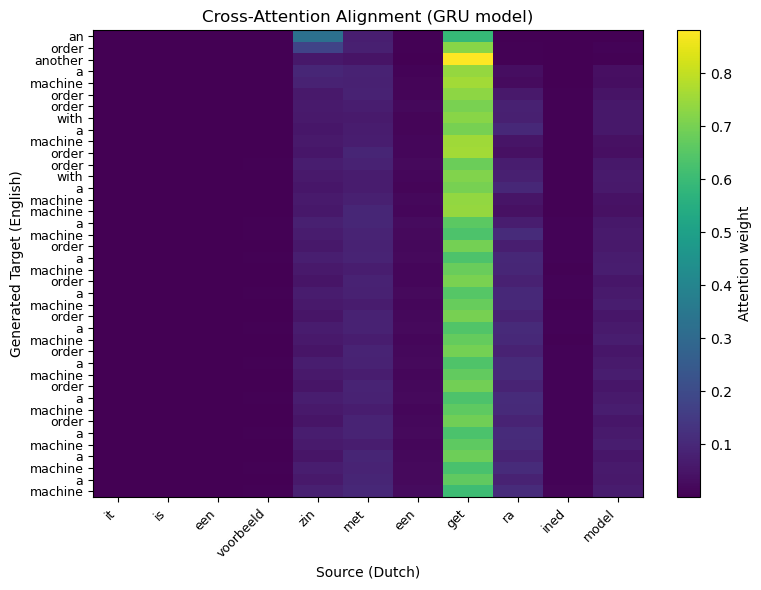

Model translation: an order another a machine order order with a machine order order with a machine machine a machine order a machine order a machine order a machine order a machine order a machine order a machine a machine a machine


In [ ]:
import torch
import matplotlib.pyplot as plt

def visualize_attention_gru(model, tok, src_sentence, max_len=40):
    device = next(model.parameters()).device
    model.eval()

    BOS = tok.token_to_id("<bos>")
    EOS = tok.token_to_id("<eos>")
    PAD = tok.token_to_id("<pad>")

    src_ids = tok.encode(src_sentence.strip()).ids
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(1)

    encoder_outputs, hidden = model.encoder(src_tensor)

    generated_ids = []
    attention_steps = []

    input_token = torch.tensor([BOS], dtype=torch.long, device=device)

    for t in range(max_len):
        logits, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)

        attn_weights = attn_weights.squeeze(1)
        attention_steps.append(attn_weights.detach().cpu())

        next_id = int(torch.argmax(logits, dim=1).item())
        if next_id == EOS:
            break

        generated_ids.append(next_id)
        input_token = torch.tensor([next_id], dtype=torch.long, device=device)

    if len(attention_steps) == 0:
        raise RuntimeError("No decoding steps produced any attention.")

    attn_matrix = torch.stack(attention_steps, dim=0)

    src_tokens = [tok.id_to_token(i) for i in src_ids]
    tgt_tokens = [tok.id_to_token(i) for i in generated_ids]
    if len(tgt_tokens) == 0:
        tgt_tokens = ["<eos>"]

    tgt_len, src_len = attn_matrix.shape
    src_tokens = src_tokens[:src_len]
    tgt_tokens = tgt_tokens[:tgt_len]
    attn_matrix = attn_matrix[:tgt_len, :src_len]

    plt.figure(figsize=(8, 6))
    plt.imshow(attn_matrix.numpy(), aspect="auto", interpolation="nearest")
    plt.colorbar(label="Attention weight")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right", fontsize=9)
    plt.yticks(range(len(tgt_tokens)), tgt_tokens, fontsize=9)
    plt.xlabel("Source (Dutch)")
    plt.ylabel("Generated Target (English)")
    plt.title("Cross-Attention Alignment (GRU model)")
    plt.tight_layout()
    plt.show()

    decoded_translation = tok.decode(generated_ids)
    return decoded_translation, attn_matrix, src_tokens, tgt_tokens

base_tokenizer = tokenizer_original 

translation, attn_matrix, src_tok, tgt_tok = visualize_attention_gru(
    model,
    base_tokenizer,
    "Dit is een voorbeeld zin met een getrained model",
    max_len=40
)

print("Model translation:", translation)


# Conclusion

The Seq2Seq model with attention successfully learns basic Dutch-to-English translation patterns and produces interpretable attention alignments.  
However, translation quality remains limited; sentences are often incomplete or grammatically incorrect.

This underperformance is mainly due to restricted computational resources.  
The model was trained with a relatively small architecture, limited dataset size, and few epochs.  
Larger models with more layers, higher embedding dimensions, and longer training on GPUs or TPUs would capture richer linguistic relationships and produce more fluent translations.

Despite these constraints, the experiment demonstrates that even a modest GRU-based architecture can learn meaningful alignments and serve as a strong foundation for more powerful neural translation systems.